In [ ]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

# Imrproved CNN with Image Augmentation and Transfer Learning

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras as keras

In [15]:
base_dir = 'data\\cats_and_dogs_filtered'
train_dir = os.path.join(base_dir,'train')
validation_dir = os.path.join(base_dir, 'validation')
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

## Image Preprocessing and Augmentation

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
# Constants
BATCH_SIZE = 20
IMG_SHAPE = 150

In [26]:
# Rescaling
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fetch Data and Resize
train_data_gen = image_gen_train.flow_from_directory(
    batch_size = BATCH_SIZE,
    directory = train_dir,
    shuffle = True,
    target_size = (IMG_SHAPE,IMG_SHAPE),
    class_mode = 'binary'
)

Found 2000 images belonging to 2 classes.


In [19]:
image_gen_val = ImageDataGenerator(rescale=1./255)
val_data_gen = image_gen_val.flow_from_directory(
    batch_size=BATCH_SIZE,
    directory=validation_dir,
    shuffle=True,
    target_size = (IMG_SHAPE,IMG_SHAPE),
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.


In [24]:
def plotImages(images_arr):
  fig, axes = plt.subplots(1,len(images_arr), figsize=(20,20))
  axes =axes.flatten()
  for img,ax in zip(images_arr,axes):
    ax.imshow(img)
  plt.tight_layout()
  plt.show()

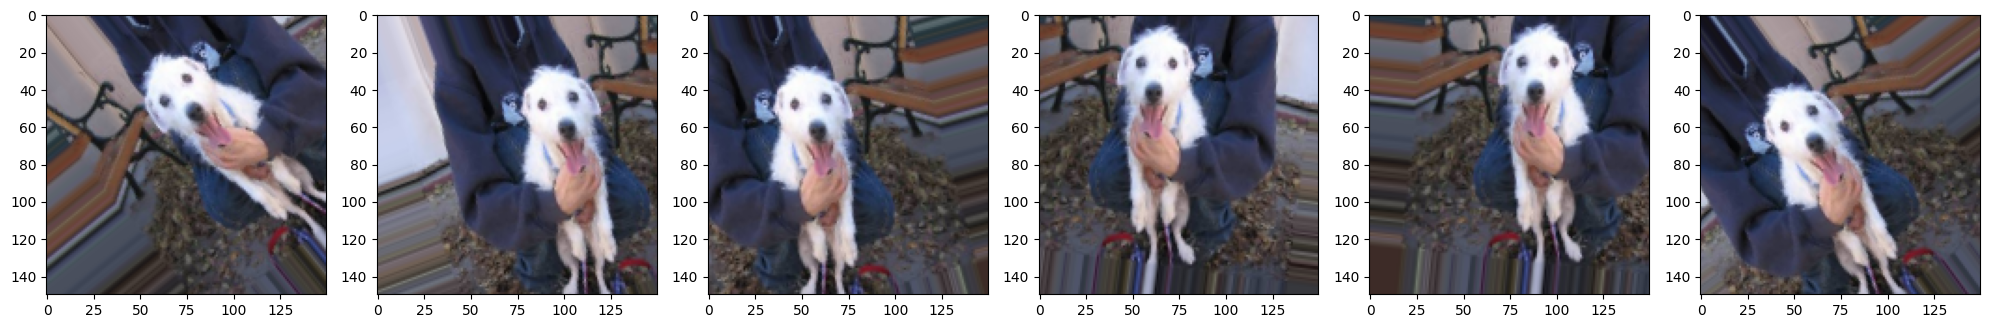

In [27]:
augmented_images = [train_data_gen[0][0][12] for i in range(6)]
plotImages(augmented_images)

## Transfer Learning

In [30]:
from keras.applications import vgg16

### VGG16 Pre-Trained Model

In [31]:
vgg = vgg16.VGG16(include_top=False, weights='imagenet', input_shape=(150,150,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [33]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, InputLayer

In [36]:
output = vgg.layers[-1].output
output = Flatten()(output)
vgg_model = keras.Model(vgg.input, output)
vgg_model.trainable=False
for layer in vgg_model.layers:
    layer.trainable=False

### Build Custom Classifier

In [39]:
model = keras.Sequential()
model.add(vgg_model)
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.15))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_1 (Functional)       │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,942,401 (72.26 MB)

 Trainable params: 4,227,713 (16.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Model Compile

In [45]:
model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
    metrics = ['binary_accuracy']
)

Early Stopping Callback

In [46]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=2)

Train our Model

In [47]:
history = model.fit(
    train_data_gen,
    steps_per_epoch=100,
    epochs=50,
    validation_data=val_data_gen,
    validation_steps=50,
    callbacks=[callback],
    verbose=2
)

Epoch 1/50
100/100 - 180s - 2s/step - binary_accuracy: 0.6760 - loss: 0.7385 - val_binary_accuracy: 0.8340 - val_loss: 0.3717
Epoch 2/50
100/100 - 213s - 2s/step - binary_accuracy: 0.7800 - loss: 0.4665 - val_binary_accuracy: 0.8550 - val_loss: 0.3300
Epoch 3/50
100/100 - 203s - 2s/step - binary_accuracy: 0.8015 - loss: 0.4262 - val_binary_accuracy: 0.8770 - val_loss: 0.3011
Epoch 4/50
100/100 - 216s - 2s/step - binary_accuracy: 0.8305 - loss: 0.3845 - val_binary_accuracy: 0.8720 - val_loss: 0.3149
Epoch 5/50
100/100 - 222s - 2s/step - binary_accuracy: 0.8250 - loss: 0.3907 - val_binary_accuracy: 0.8820 - val_loss: 0.2981
Epoch 6/50
100/100 - 215s - 2s/step - binary_accuracy: 0.8340 - loss: 0.3824 - val_binary_accuracy: 0.8810 - val_loss: 0.2825
Epoch 7/50
100/100 - 205s - 2s/step - binary_accuracy: 0.8505 - loss: 0.3498 - val_binary_accuracy: 0.8270 - val_loss: 0.4648
Epoch 8/50
100/100 - 207s - 2s/step - binary_accuracy: 0.8470 - loss: 0.3546 - val_binary_accuracy: 0.8800 - val_loss:

Training Curve Validation

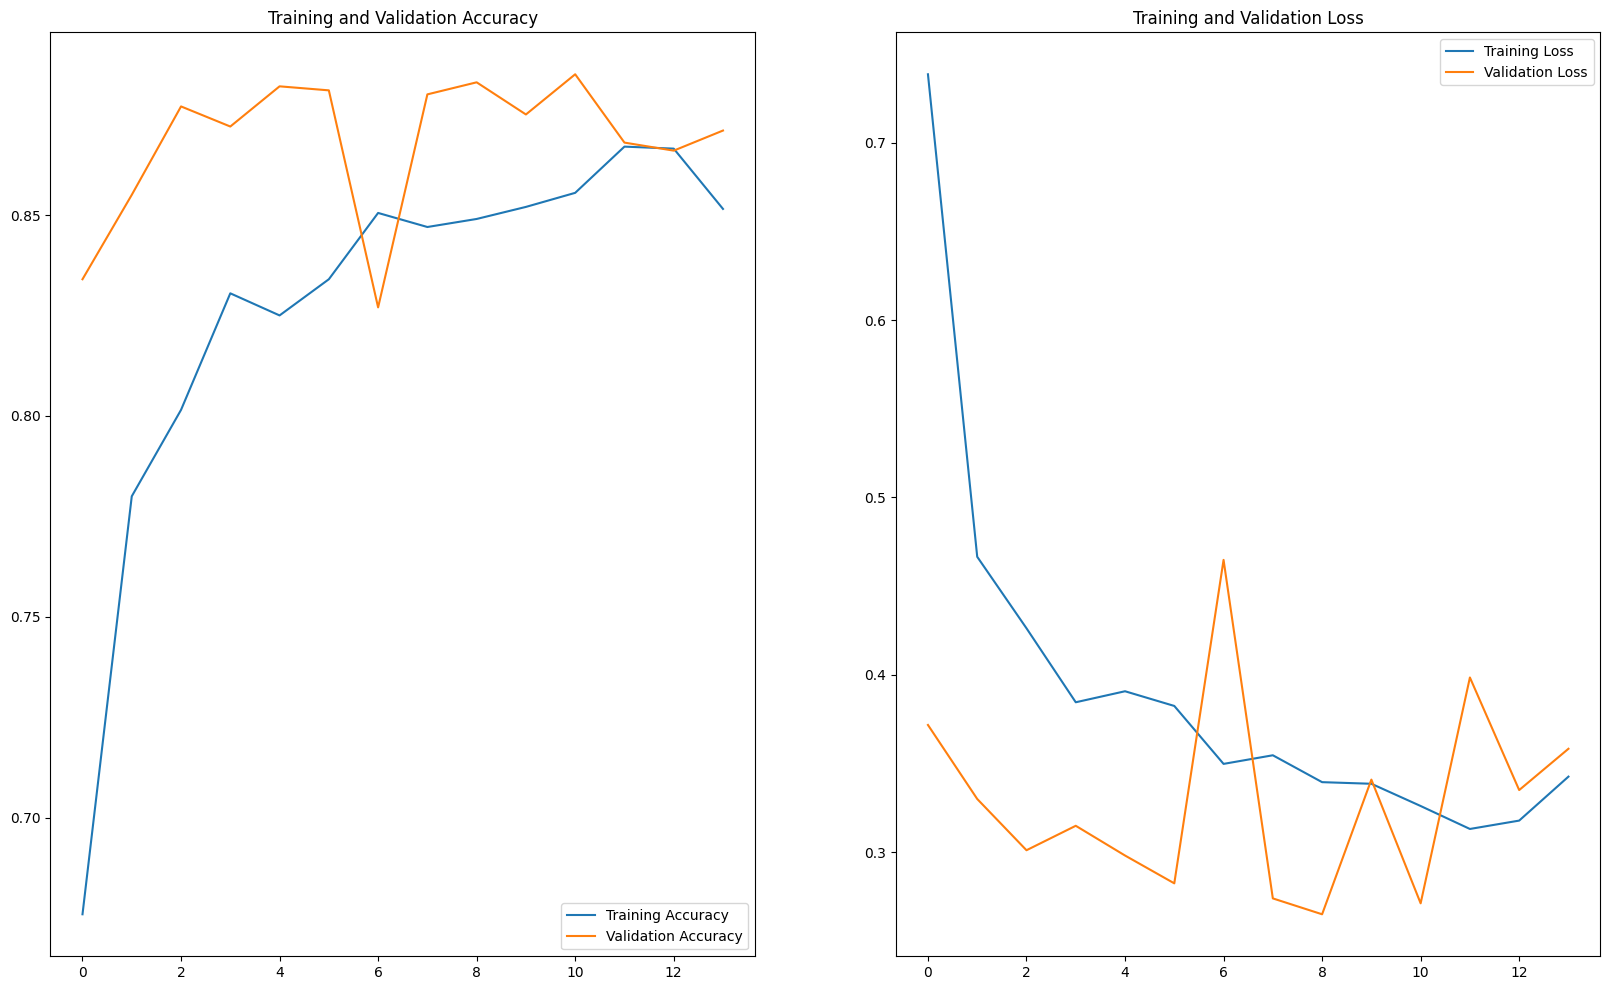

In [48]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 12))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Predictions Display Function

In [49]:
from keras.preprocessing.image import load_img, img_to_array

In [50]:
def cat_or_dog(file):
    img = load_img(file, target_size=(IMG_SHAPE,IMG_SHAPE))
    img = img_to_array(img)
    img = np.expand_dims(img,axis=0)

    probs = model.predict(img)

    if probs[0][0] == 1:
        result = 'dog'
    else:
        result = 'cat'

    plt.imshow(plt.imread(file))
    plt.show()

    print("This is clearly a " + result + "!")

    return probs


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


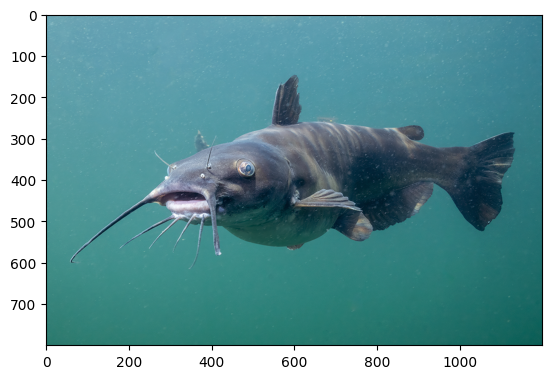

This is clearly a dog!


array([[1.]], dtype=float32)

In [59]:
cat_or_dog(r"C:\Users\Mikael Huff\Downloads\catfish.webp")